In [1]:
import os
from IPython.display import display, Image
from pathlib import Path

from Train_Best_Model.train_best_model_cv import config, run_cv_training
from Train_Ensemble.train_ensemble import run_ensemble_cv

# Train Single Model
This section trains a single model using the best hyperparameters found in the hyperparameter tuning step.

In [2]:
# Set hyperparameter directory
hp_dir='Hyperparameter_Tuning/output'

# Set desired output directory for single model training
# NOTE: You cannot use a directory that already exists (to avoid overwriting)
single_model_output_dir = 'Train_Best_Model/output/land_model_best_cv'

# Set path to file containing training data
npz_path='ML_Data_Preprocessing/output/assembled_npz/full_training_data.npz'


In [3]:
# Run single model training or, if it already exists, print results
if not os.path.exists(single_model_output_dir):
    run_cv_training(overrides = 
        config(
            npz_path='ML_Data_Preprocessing/output/assembled_npz/full_training_data.npz',
            test_indices_path='Hyperparameter_Tuning/output/test_indices.pkl',
            output_dir=single_model_output_dir,
            n_folds=10,
            epochs=150,
            hp_dir = hp_dir,
            cv_seed=42,
        )
    )
else:
    print(f"Single model output directory {single_model_output_dir} already exists. Skipping training.")
    print(f"Results from previous run:")
    print((Path(single_model_output_dir) / 'cv_summary.txt').read_text())

Single model output directory Train_Best_Model/output/land_model_best_cv already exists. Skipping training.
Results from previous run:
CV Training Summary

Date: 2025-08-09 18:17:56
Folds: 10
Epochs: 150
Batch size: 64

Averaged metrics (mm):
  RMSE: 100.916566 mm
  MAE:  66.405529 mm
  MSE:  10218.104590 mm²
  R²:   0.775232



# Train Ensemble Model
This section trains the ensemble model using the best hyperparameters found in the hyperparameter tuning step.

In [4]:
# Set output directory for ensemble models
ensemble_output_dir='Train_Ensemble/output/simple_ensemble_cv'

In [5]:
# Run the ensemble cross-validation training
run_ensemble_cv(
    output_dir=ensemble_output_dir,
    n_folds = 15,
    epochs=150,
    n_models_per_fold=5,
    test_indices_path=hp_dir + '/test_indices.pkl', # To keep test set constant
    hp_dir=hp_dir,
    npz_path=npz_path)

Detected existing completed run at Train_Ensemble/output/simple_ensemble_cv. Skipping training and metrics printing.


{'status': 'already_completed',
 'output_dir': 'Train_Ensemble/output/simple_ensemble_cv'}

In [6]:
# Print summary of ensemble training
print((Path(ensemble_output_dir) / 'ensemble_summary.txt').read_text())

K-Fold CV Ensemble Model with 15 Folds
Each fold contains 5 models
Total models: 75

Hyperparameters:
  na: 64
  nb: 128
  dropout_rate: 0.5
  l2_reg: 1e-06
  learning_rate: 0.0001
  weight_decay: 1e-07
  batch_size: 64
  local_dem_units: 256
  regional_dem_units: 256
  month_units: 16
  climate_units: 512
  use_residual: True
  activation: relu
  output_activation: softplus

Cross-Validation Results:
  Fold 1: R² = 0.7871, RMSE = 98.3750 mm, MAE = 64.2135 mm
  Fold 2: R² = 0.8016, RMSE = 94.9727 mm, MAE = 63.5058 mm
  Fold 3: R² = 0.7905, RMSE = 97.5821 mm, MAE = 64.4675 mm
  Fold 4: R² = 0.7866, RMSE = 98.4856 mm, MAE = 65.9395 mm
  Fold 5: R² = 0.7964, RMSE = 96.2091 mm, MAE = 62.7799 mm
  Fold 6: R² = 0.7859, RMSE = 98.6628 mm, MAE = 66.2314 mm
  Fold 7: R² = 0.7767, RMSE = 100.7467 mm, MAE = 65.7477 mm
  Fold 8: R² = 0.7893, RMSE = 97.8771 mm, MAE = 66.2813 mm
  Fold 9: R² = 0.7997, RMSE = 95.4183 mm, MAE = 62.4814 mm
  Fold 10: R² = 0.7859, RMSE = 98.6485 mm, MAE = 64.4539 mm
  F

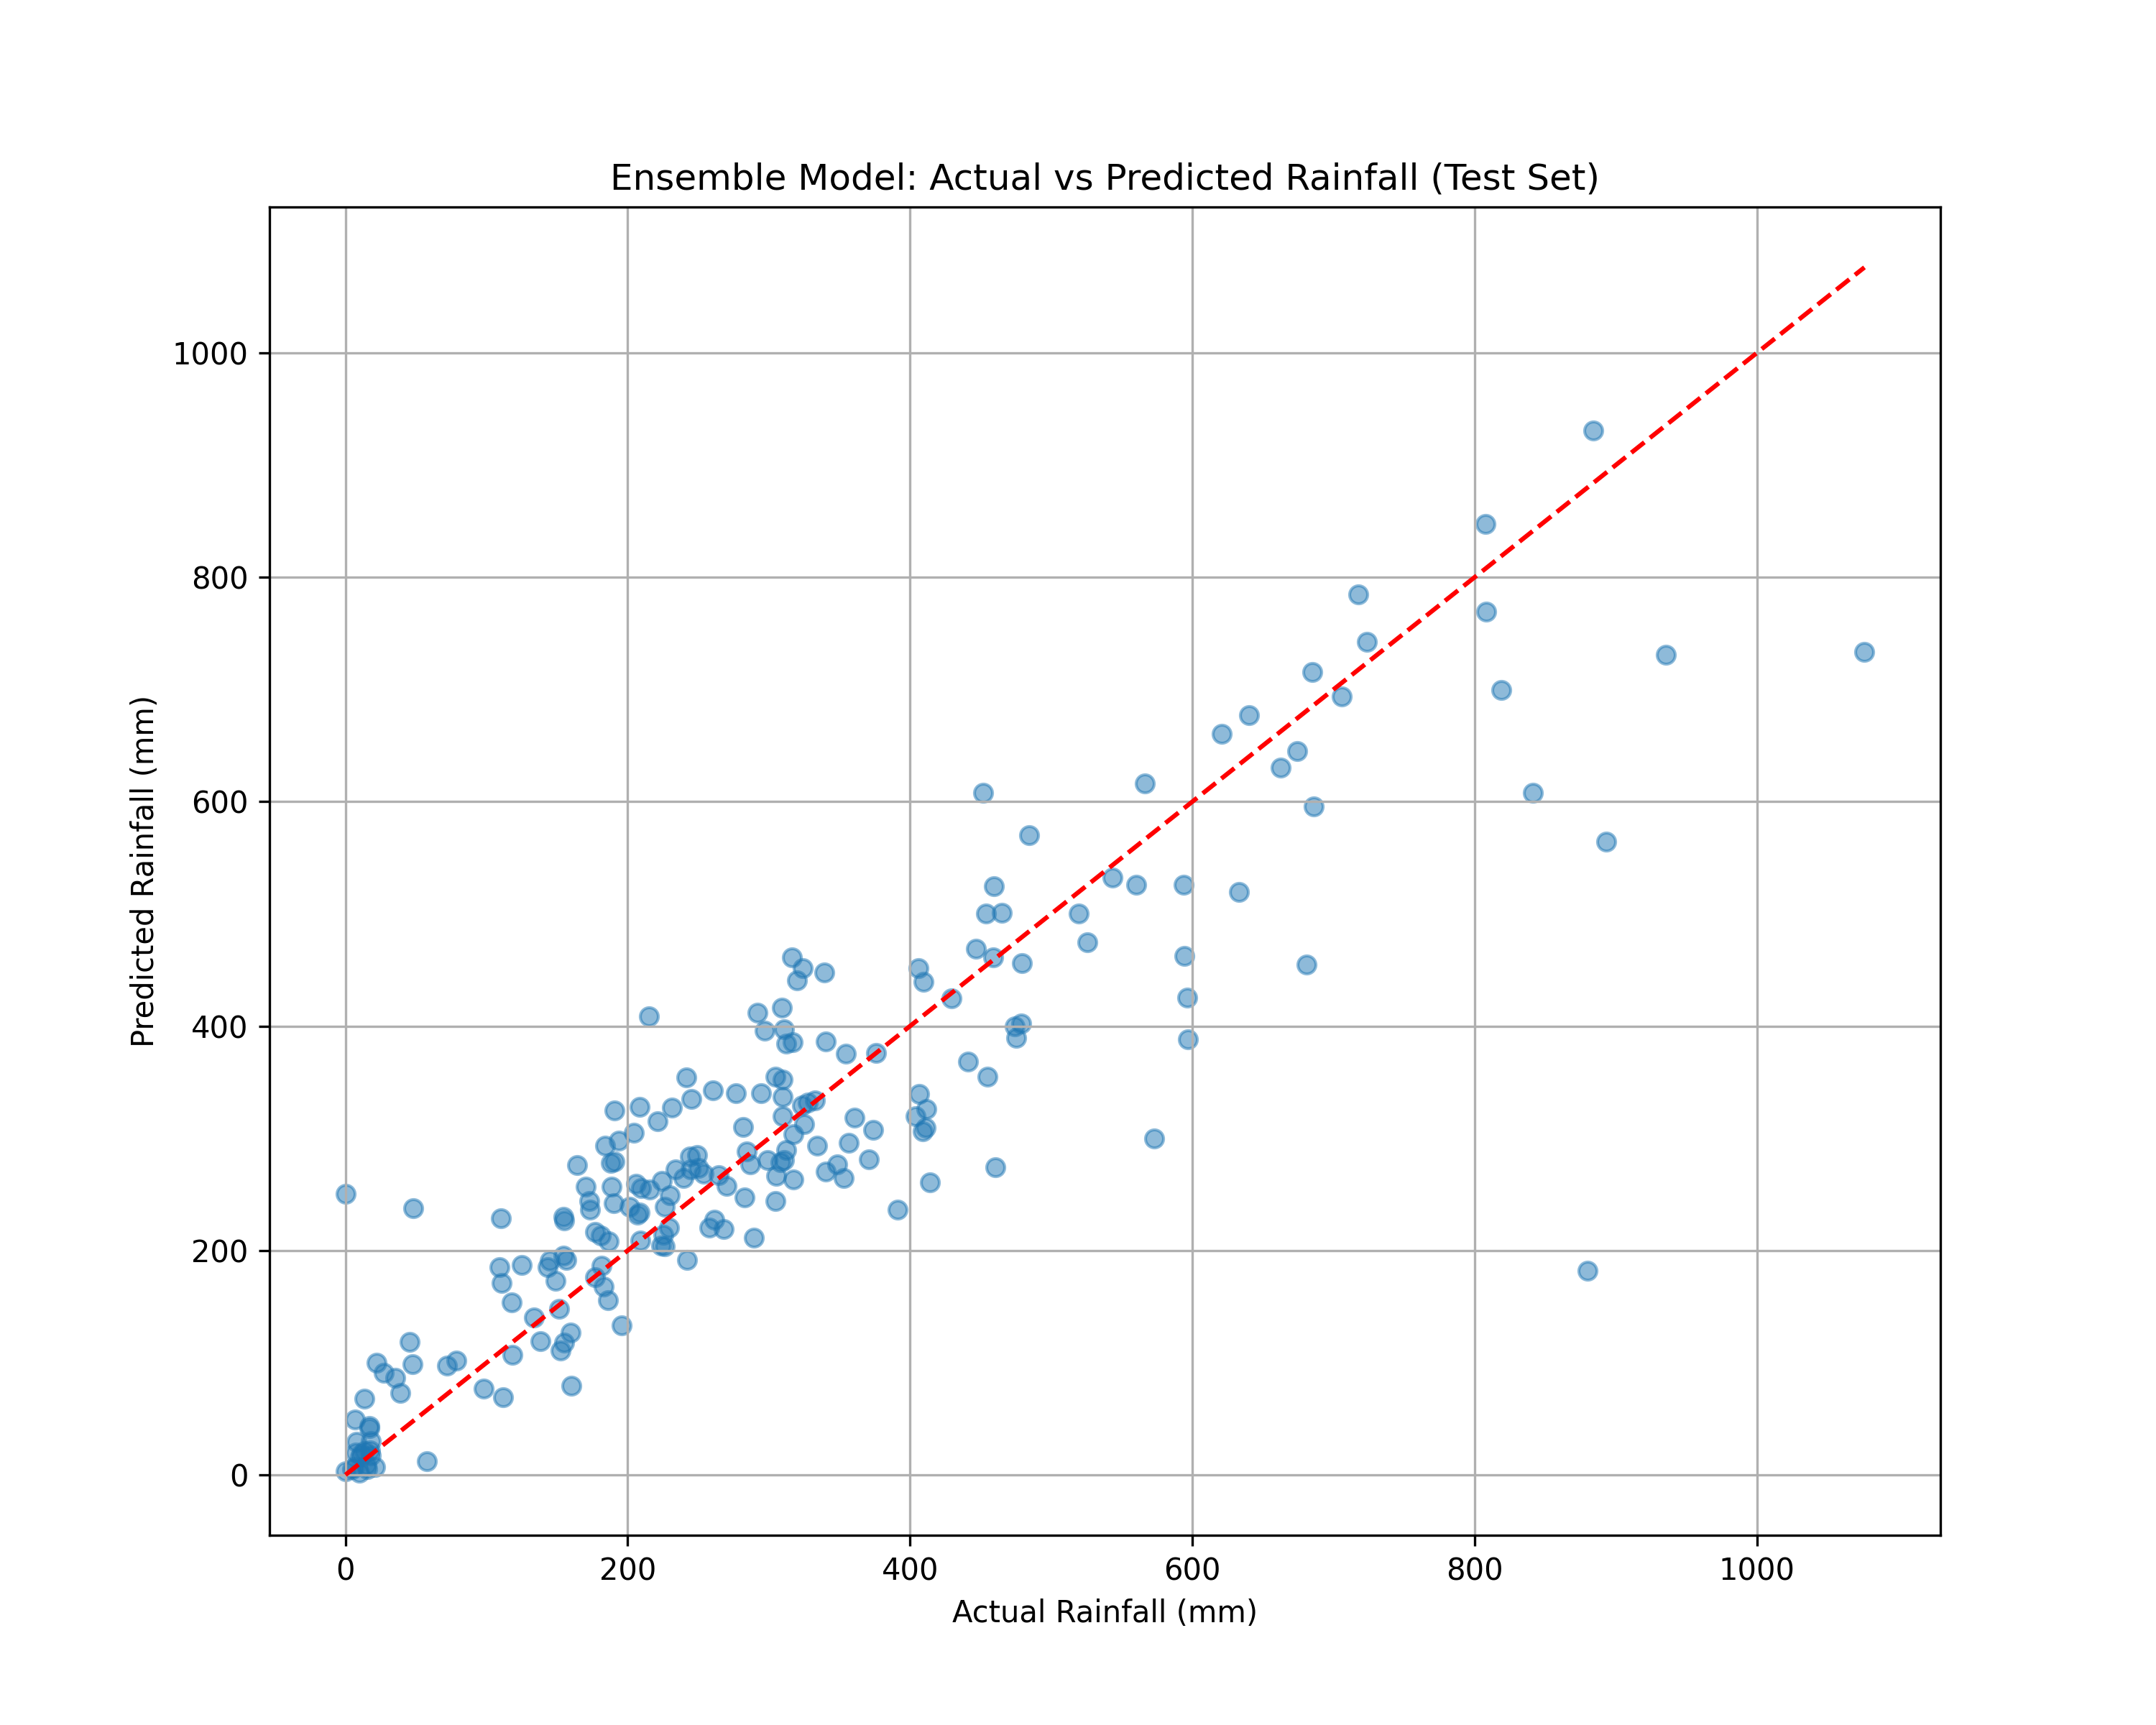

In [7]:
# Set ensemble visualization path
ensemble_test_viz_path = os.path.join(ensemble_output_dir, 'ensemble_test_predictions.png')
# Load the test predictions visualization
ensemble_test_viz = display(Image(filename=ensemble_test_viz_path))